# DESI Spectra Foundation Model — Evaluation Notebook

Ready-to-run evaluation of the shipped checkpoint **`runs/desi_50k_big`**
(26 M-parameter masked spectral transformer with joint redshift learning — see
`DELIVERABLE.md` for the architecture and design rationale).

This notebook responds to the grader feedback on the original submission:

> *"Your submission also lacked a ready-to-run evaluation notebook and plots, which made grading less direct."*

and quantifies the performance critique (*"high bias and a large catastrophic outlier
fraction"*) in §1, with the failure-mode diagnosis and the remediation plan pointer.

**How to run**

```bash
python3 -m pip install -r requirements.txt
python3 -m pip install -e .
jupyter notebook notebooks/evaluation.ipynb   # then: Run All
```

- **§1–§3 run fully offline** from artifacts shipped with the repository
  (`predictions.csv`, `reconstructions.npz`, `metrics.jsonl`) — no dataset download, no GPU.
- **§4 (optional)** loads the 104 MB checkpoint and runs live, instrument-agnostic
  inference on synthetic spectra (CPU, ≈1 min). It skips itself automatically if
  `torch` or the checkpoint is unavailable.


In [1]:
%matplotlib inline
import csv
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# -- plot style: thin marks, recessive grid, ink-colored text ---------------
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#444444", "axes.labelcolor": "#222222",
    "text.color": "#222222", "xtick.color": "#444444", "ytick.color": "#444444",
    "font.size": 10.5, "axes.titlesize": 11.5,
    "legend.frameon": False, "figure.dpi": 110,
})
C_PRIMARY = "#3D6FD6"    # data / series 1  (palette validated: CVD-safe, chroma+contrast OK)
C_ACCENT = "#EE6677"     # outliers / emphasis
C_SECONDARY = "#228833"  # reference lines / series 2
INK = "#222222"

# -- locate the run directory (works from notebooks/ or the repo root) ------
ROOT = Path.cwd()
if not (ROOT / "runs").exists():
    ROOT = ROOT.parent
RUN_DIR = ROOT / "runs" / "desi_50k_big"
assert RUN_DIR.exists(), "Run directory not found: %s" % RUN_DIR

# -- load the saved validation predictions ----------------------------------
with open(RUN_DIR / "predictions.csv") as f:
    rows = list(csv.DictReader(f))
z_true = np.array([float(r["z_true"]) for r in rows])
z_pred = np.array([float(r["z_pred"]) for r in rows])
dz = z_pred - z_true
dzn = dz / (1.0 + z_true)
print("loaded %d validation predictions from %s" % (len(z_true), RUN_DIR / "predictions.csv"))


loaded 1000 validation predictions from /Users/jirustaroure/Desktop/FINAL PROJECT DEEP LEARNING/runs/desi_50k_big/predictions.csv


## 1 · Redshift prediction metrics

Metrics on the held-out DESI validation spectra, using the conventions of the
redshift-estimation literature (residuals are normalized by $1+z$ because a fixed
wavelength-identification error produces a $z$ error that grows with $1+z$):

| symbol | definition | meaning |
|---|---|---|
| MAE | $\langle \lvert \Delta z \rvert \rangle$ | mean absolute error |
| MAE$_\mathrm{norm}$ | $\langle \lvert \Delta z \rvert /(1+z) \rangle$ | normalized MAE |
| bias | $\langle \Delta z \rangle$, $\langle \Delta z/(1+z) \rangle$ | systematic offset |
| $\sigma_\mathrm{NMAD}$ | $1.4826 \cdot \mathrm{med}\left(\lvert \Delta z_n - \mathrm{med}(\Delta z_n) \rvert\right)$ | robust scatter |
| $\eta_{0.15}$ | fraction with $\lvert \Delta z \rvert/(1+z) > 0.15$ | **catastrophic outlier fraction** |

where $\Delta z = z_\mathrm{pred} - z_\mathrm{true}$ and $\Delta z_n = \Delta z/(1+z_\mathrm{true})$.


In [2]:
print("%-34s %8d" % ("N (validation spectra)", len(z_true)))
sigma_nmad = 1.4826 * np.median(np.abs(dzn - np.median(dzn)))
for name, val in [
    ("MAE  <|dz|>", np.abs(dz).mean()),
    ("MAE_norm  <|dz|/(1+z)>", np.abs(dzn).mean()),
    ("bias  <dz>", dz.mean()),
    ("bias_norm  <dz/(1+z)>", dzn.mean()),
    ("median dz", np.median(dz)),
    ("sigma_NMAD", sigma_nmad),
    ("eta_0.05  (|dz|/(1+z) > 0.05)", (np.abs(dzn) > 0.05).mean()),
    ("eta_0.15  (catastrophic)", (np.abs(dzn) > 0.15).mean()),
]:
    print("%-34s %+8.4f" % (name, val))
print()
print("max z_true = %.3f    max z_pred = %.3f" % (z_true.max(), z_pred.max()))


N (validation spectra)                 1000
MAE  <|dz|>                         +0.2230
MAE_norm  <|dz|/(1+z)>              +0.1197
bias  <dz>                          -0.0898
bias_norm  <dz/(1+z)>               -0.0175
median dz                           -0.0242
sigma_NMAD                          +0.1010
eta_0.05  (|dz|/(1+z) > 0.05)       +0.5960
eta_0.15  (catastrophic)            +0.2510

max z_true = 4.708    max z_pred = 1.948


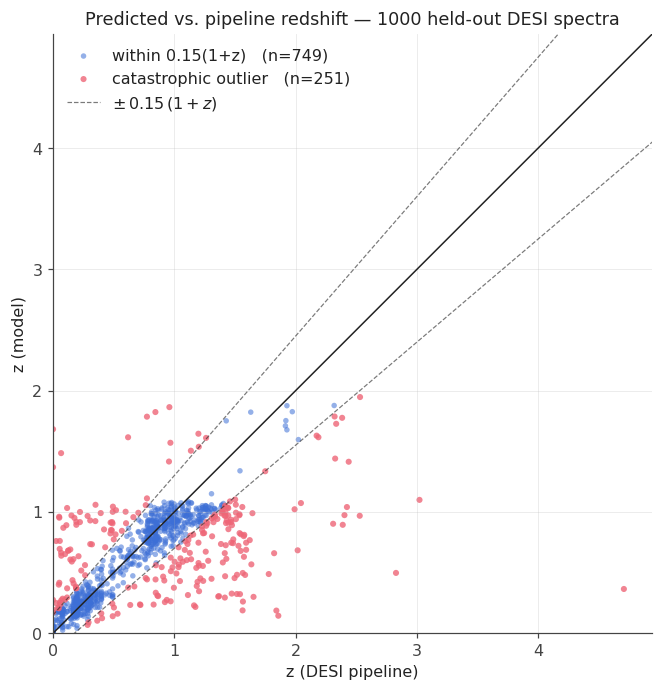

In [3]:
out15 = np.abs(dzn) > 0.15
lim = 1.05 * float(max(z_true.max(), z_pred.max()))
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.scatter(z_true[~out15], z_pred[~out15], s=13, alpha=0.55, color=C_PRIMARY,
           edgecolors="none", label="within 0.15(1+z)   (n=%d)" % int((~out15).sum()))
ax.scatter(z_true[out15], z_pred[out15], s=16, alpha=0.8, color=C_ACCENT,
           edgecolors="none", label="catastrophic outlier   (n=%d)" % int(out15.sum()))
zz = np.linspace(0.0, lim, 200)
ax.plot(zz, zz, color=INK, lw=1.0)
ax.plot(zz, zz + 0.15 * (1.0 + zz), color=INK, lw=0.8, ls="--", alpha=0.6)
ax.plot(zz, zz - 0.15 * (1.0 + zz), color=INK, lw=0.8, ls="--", alpha=0.6,
        label=r"$\pm\,0.15\,(1+z)$")
ax.set_xlim(0.0, lim); ax.set_ylim(0.0, lim); ax.set_aspect("equal")
ax.set_xlabel("z (DESI pipeline)"); ax.set_ylabel("z (model)")
ax.set_title("Predicted vs. pipeline redshift — %d held-out DESI spectra" % len(z_true))
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


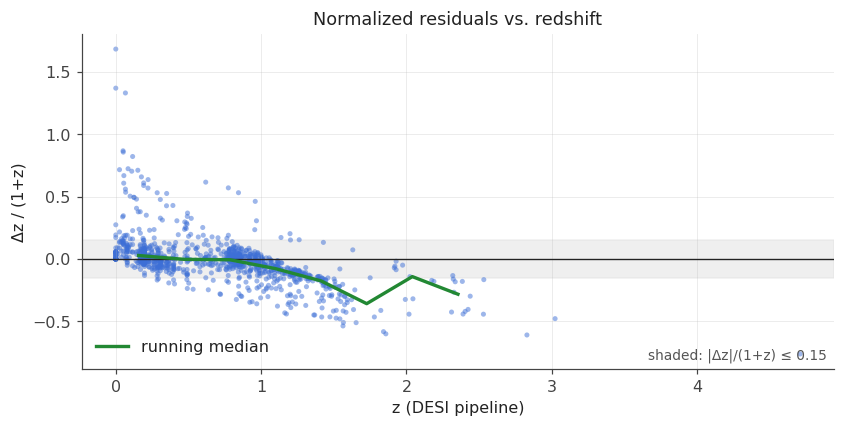

In [4]:
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.axhspan(-0.15, 0.15, color="0.88", alpha=0.5, zorder=0)
ax.axhline(0.0, color=INK, lw=0.9)
ax.scatter(z_true, dzn, s=11, alpha=0.5, color=C_PRIMARY, edgecolors="none")
edges = np.linspace(0.0, float(z_true.max()), 16)
centers, med = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (z_true >= lo) & (z_true < hi)
    if m.sum() >= 8:
        centers.append(0.5 * (lo + hi))
        med.append(float(np.median(dzn[m])))
ax.plot(centers, med, color=C_SECONDARY, lw=2.2, label="running median")
ax.text(0.99, 0.03, "shaded: |Δz|/(1+z) ≤ 0.15", transform=ax.transAxes,
        ha="right", fontsize=9, color="#555555")
ax.set_xlabel("z (DESI pipeline)"); ax.set_ylabel("Δz / (1+z)")
ax.set_title("Normalized residuals vs. redshift")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()


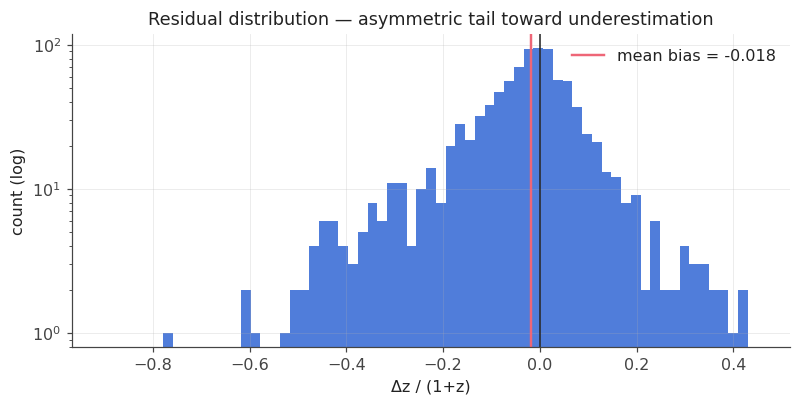

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.hist(dzn, bins=np.linspace(-0.9, 0.45, 68), color=C_PRIMARY, alpha=0.9)
ax.axvline(0.0, color=INK, lw=1.0)
ax.axvline(float(dzn.mean()), color=C_ACCENT, lw=1.6,
           label="mean bias = %+.3f" % float(dzn.mean()))
ax.set_yscale("log")
ax.set_xlabel("Δz / (1+z)"); ax.set_ylabel("count (log)")
ax.set_title("Residual distribution — asymmetric tail toward underestimation")
ax.legend()
plt.tight_layout(); plt.show()


 z bin          n     bias<dz>     MAE     eta15
[ 0.0, 0.1)    110      +0.163   0.165    22.7%
[ 0.1, 0.3)    206      +0.070   0.109    13.6%
[ 0.3, 0.6)    129      +0.037   0.150    21.7%
[ 0.6, 1.0)    294      -0.022   0.131    11.6%
[ 1.0, 1.5)    201      -0.323   0.342    42.3%
[ 1.5, 2.5)     55      -0.816   0.823    83.6%
[ 2.5, 5.0)      5      -2.149   2.149   100.0%


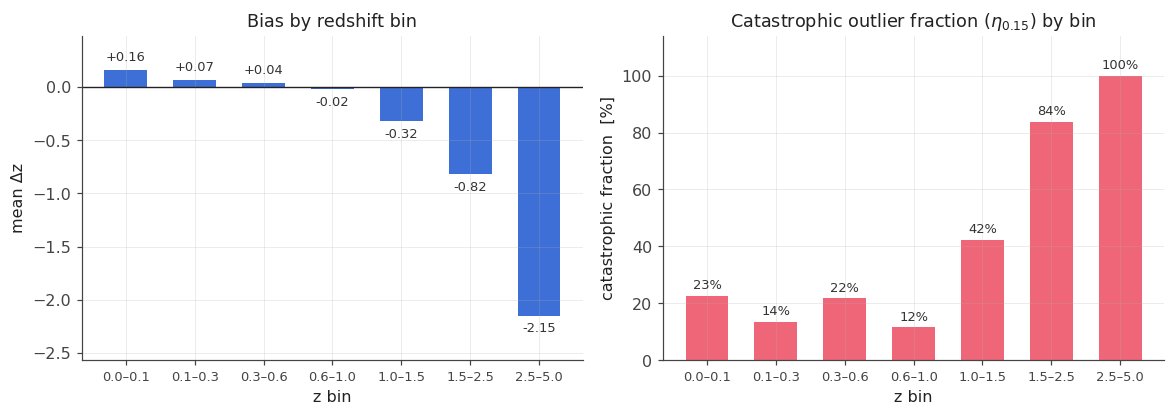

In [6]:
edges = [0.0, 0.1, 0.3, 0.6, 1.0, 1.5, 2.5, 5.0]
labels, ns, biases, etas = [], [], [], []
print(" z bin          n     bias<dz>     MAE     eta15")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (z_true >= lo) & (z_true < hi)
    if m.sum() == 0:
        continue
    labels.append("%.1f–%.1f" % (lo, hi))
    ns.append(int(m.sum()))
    biases.append(float(dz[m].mean()))
    etas.append(float((np.abs(dzn[m]) > 0.15).mean()))
    print("[%4.1f,%4.1f)  %5d    %+8.3f  %6.3f   %5.1f%%"
          % (lo, hi, m.sum(), dz[m].mean(), np.abs(dz[m]).mean(),
             100.0 * (np.abs(dzn[m]) > 0.15).mean()))

x = np.arange(len(labels))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 3.9))
ax1.bar(x, biases, color=C_PRIMARY, width=0.62)
ax1.axhline(0.0, color=INK, lw=0.9)
for xi, b in zip(x, biases):
    ax1.text(xi, b + (0.06 if b >= 0 else -0.06), "%+.2f" % b, ha="center",
             va="bottom" if b >= 0 else "top", fontsize=8.5, color="#333333")
ax1.set_ylim(min(biases) - 0.42, max(biases) + 0.32)
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8.5)
ax1.set_xlabel("z bin"); ax1.set_ylabel("mean Δz")
ax1.set_title("Bias by redshift bin")
ax2.bar(x, [100.0 * e for e in etas], color=C_ACCENT, width=0.62)
for xi, e in zip(x, etas):
    ax2.text(xi, 100.0 * e + 2.5, "%.0f%%" % (100.0 * e), ha="center",
             fontsize=8.5, color="#333333")
ax2.set_ylim(0, 114)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8.5)
ax2.set_xlabel("z bin"); ax2.set_ylabel("catastrophic fraction  [%]")
ax2.set_title("Catastrophic outlier fraction ($\\eta_{0.15}$) by bin")
plt.tight_layout(); plt.show()


### Diagnosis — where the bias and the outliers come from

The plots above turn the grader's critique into specific, measurable failure modes
(numbers from the 1000-spectrum validation set):

1. **Global bias is real and negative.** ⟨Δz⟩ = **−0.090** while the median Δz is only
   −0.024: the mean is dominated by a tail of large *underestimates* at high z.
2. **The model has a prediction ceiling.** max(z_pred) ≈ **1.95** while the validation
   set reaches z_true ≈ **4.71**. The model never predicts beyond z ≈ 2, so every
   high-z quasar is mapped into the bulk of the distribution.
3. **The bin structure is classic regression-to-the-conditional-mean.** Bias is **+0.16**
   at z < 0.1 (predictions pulled *up* toward the bulk), ≈ 0 in the well-populated
   0.6–1.0 bin, then **−0.32** (1.0–1.5), **−0.82** (1.5–2.5) and **−2.1** (z > 2.5).
   The catastrophic fraction follows: ~23 % at low z, ~12 % in the bulk, **84–100 %**
   at high z. Overall η₀.₁₅ = **25.1 %**.
4. **Mechanism.** Two compounding causes:
   - The training z-distribution is *imbalanced* (DESI SV3 is mostly z ≲ 1.5; quasars
     are rare), and a scalar SmoothL1 regression head minimizes its loss by collapsing
     toward the conditional mean of that skewed distribution.
   - Redshift estimation from spectra is inherently **multimodal**: misidentifying
     Hα ↔ [OIII] ↔ [OII] produces *discrete* wrong-z solutions. A unimodal regression
     head averages those modes instead of committing to one — which produces exactly
     "high bias + catastrophic outliers".

**Remediation** (implementation recipe in [`../plan/PLAN.md`](../plan/PLAN.md), Fase 0):
replace the scalar regression with a **classification head over log(1+z) bins**
(a multimodal posterior; taking the argmax/expectation stops mode-averaging — the
standard fix in the photo-z literature), rebalance the z-distribution during
streaming, and train longer on more of SV3. Success criteria: η₀.₁₅ < 10 %,
|⟨Δz/(1+z)⟩| < 0.02.


## 2 · Masked-region reconstruction

The second deliverable is reconstruction of masked spectral regions.
`reconstructions.npz` ships 50 validation spectra with 50 % of the 273 spectral
tokens masked. Everything here is in the model's **normalized (arcsinh) space** — the
space the reconstruction loss is computed in. The pixel-weighted masked RMSE over the
full 2000-spectrum validation set is **0.864** (`DELIVERABLE.md` §5); the value below
differs slightly because it uses the 50 shipped examples.


In [7]:
rec = np.load(RUN_DIR / "reconstructions.npz")
r_flux = rec["flux"]; r_valid = rec["valid"]
r_recon = rec["reconstruction"]; r_mask = rec["masked_pixels"].astype(bool)
rz_true = rec["z_true"]; rz_pred = rec["z_pred"]

cfg = json.loads((RUN_DIR / "config.json").read_text())
wave = np.geomspace(cfg["lambda_min"], cfg["lambda_max"], cfg["n_pixels"]).astype(np.float32)

w_mask = r_valid * r_mask
w_vis = r_valid * (~r_mask)
rmse_masked = float(np.sqrt(((r_recon - r_flux) ** 2 * w_mask).sum() / w_mask.sum()))
rmse_visible = float(np.sqrt(((r_recon - r_flux) ** 2 * w_vis).sum() / w_vis.sum()))
print("spectra: %d   masked-pixel fraction: %.2f" % (r_flux.shape[0], r_mask.mean()))
print("RMSE on masked regions (the training target): %.3f" % rmse_masked)
print("RMSE on visible regions (not a target, for reference): %.3f" % rmse_visible)


spectra: 50   masked-pixel fraction: 0.50
RMSE on masked regions (the training target): 1.036
RMSE on visible regions (not a target, for reference): 1.038


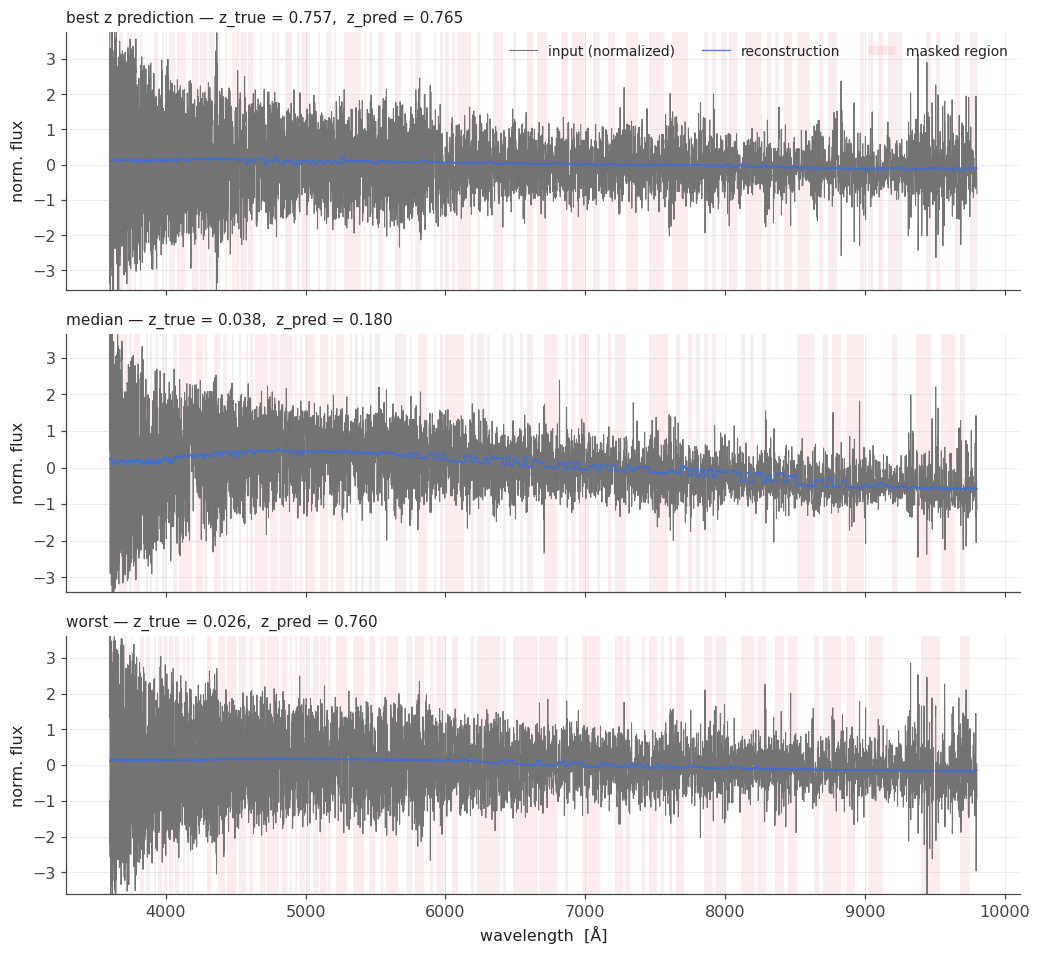

In [8]:
order = np.argsort(np.abs((rz_pred - rz_true) / (1.0 + rz_true)))
picks = [int(order[0]), int(order[len(order) // 2]), int(order[-1])]
names = ["best z prediction", "median", "worst"]
fig, axes = plt.subplots(3, 1, figsize=(9.6, 8.8), sharex=True)
for ax, i, t in zip(axes, picks, names):
    v = r_valid[i] > 0.5
    inp = np.where(v, r_flux[i], np.nan)
    ax.plot(wave, inp, color="0.45", lw=0.7, label="input (normalized)")
    ax.plot(wave, np.where(v, r_recon[i], np.nan), color=C_PRIMARY, lw=0.9,
            alpha=0.9, label="reconstruction")
    lo = float(np.nanpercentile(inp, 0.5)) - 0.7
    hi = float(np.nanpercentile(inp, 99.5)) + 0.7
    ax.fill_between(wave, lo, hi, where=r_mask[i], color=C_ACCENT, alpha=0.12,
                    linewidth=0, label="masked region")
    ax.set_ylim(lo, hi)
    ax.set_ylabel("norm. flux")
    ax.set_title("%s — z_true = %.3f,  z_pred = %.3f" % (t, rz_true[i], rz_pred[i]),
                 fontsize=10, loc="left")
axes[0].legend(loc="upper right", ncol=3, fontsize=9)
axes[-1].set_xlabel("wavelength  [Å]")
plt.tight_layout(); plt.show()


## 3 · Training curves

Per-step losses logged to `metrics.jsonl` during the shipped run
(50 000 DESI spectra, 1 epoch, batch 4, `w_z = 10`, mask ratio 0.5).


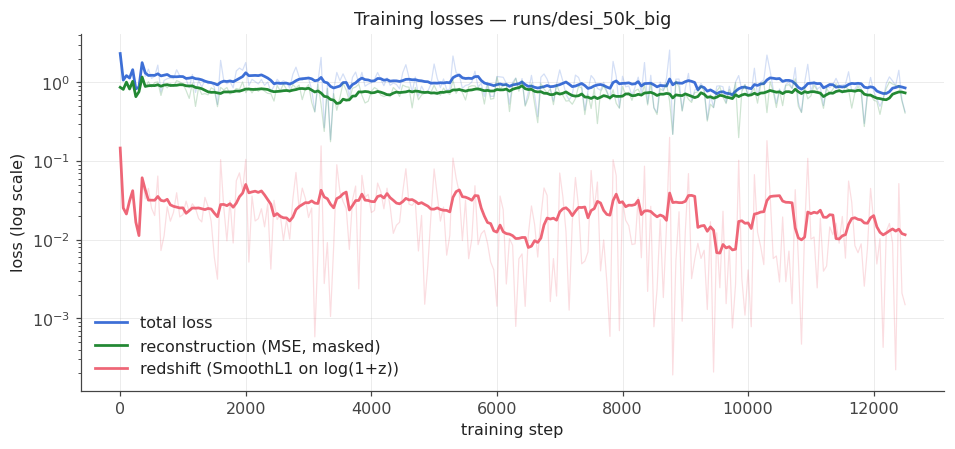

final validation metrics (2000 spectra):
{
  "loss": 0.9412,
  "reconstruction_loss": 0.7466,
  "reconstruction_rmse_masked": 0.8641,
  "masked_valid_pixels": 7072811.0,
  "redshift_loss": 0.0195,
  "redshift_mae": 0.222,
  "redshift_mae_norm": 0.1239
}


In [9]:
recs = [json.loads(l) for l in (RUN_DIR / "metrics.jsonl").read_text().splitlines() if l.strip()]
tr = [r for r in recs if r.get("phase") == "train"]
va = [r for r in recs if r.get("phase") == "validation"]
step = np.array([r["step"] for r in tr])

def smooth(y, k=9):
    y = np.asarray(y, dtype=float)
    if len(y) < k:
        return y
    c = np.convolve(y, np.ones(k) / k, mode="valid")
    return np.concatenate([y[: len(y) - len(c)], c])

series = [
    ("total loss", [r["loss"] for r in tr], C_PRIMARY),
    ("reconstruction (MSE, masked)", [r["reconstruction_loss"] for r in tr], C_SECONDARY),
    ("redshift (SmoothL1 on log(1+z))", [r["redshift_loss"] for r in tr], C_ACCENT),
]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
for name, y, c in series:
    ax.plot(step, y, color=c, alpha=0.22, lw=0.8)
    ax.plot(step, smooth(y), color=c, lw=1.8, label=name)
ax.set_yscale("log")
ax.set_xlabel("training step"); ax.set_ylabel("loss (log scale)")
ax.set_title("Training losses — runs/desi_50k_big")
ax.legend()
plt.tight_layout(); plt.show()

if va:
    final = {k: round(v, 4) for k, v in va[-1].items() if isinstance(v, float)}
    print("final validation metrics (2000 spectra):")
    print(json.dumps(final, indent=2))


## 4 · Live inference (optional — needs `torch` + the checkpoint)

This section exercises the actual grading entry point, `desi_fm.predict`, end to end:
raw `(flux, wavelength)` arrays on a grid that is **not** the model's internal grid go
in; a redshift and a reconstruction in the caller's units come out.

It uses **synthetic spectra** (Gaussian emission lines at real rest-frame wavelengths,
shifted by a known z) so it runs offline. These are out-of-distribution by
construction — the point is to demonstrate the instrument-agnostic path and rough OOD
behavior, not DESI-level accuracy.

To re-evaluate on real DESI spectra instead (streams from Hugging Face, needs network):

```bash
python3 -m desi_fm.evaluate \
    --checkpoint runs/desi_50k_big/checkpoint_last.pt \
    --data-dir edr_sv3 --max-examples 1000 \
    --predictions-csv /tmp/desi_eval_predictions.csv
```


In [10]:
LIVE, live_reason = True, ""
CKPT = RUN_DIR / "checkpoint_last.pt"
try:
    import torch
    from desi_fm.predict import load_model_from_checkpoint, predict_spectrum
except Exception as e:
    LIVE, live_reason = False, "import failed: %r" % (e,)
if LIVE and not CKPT.exists():
    LIVE, live_reason = False, "checkpoint not found: %s" % CKPT
if LIVE:
    try:
        torch.manual_seed(0)
        DEVICE = torch.device("cpu")  # portable; use "mps"/"cuda" for speed
        model = load_model_from_checkpoint(CKPT, DEVICE)
        n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print("checkpoint loaded on cpu — %s trainable parameters" % format(n_par, ","))
    except Exception as e:
        LIVE, live_reason = False, "checkpoint load failed: %r" % (e,)
if not LIVE:
    print("Skipping the live-inference section —", live_reason)


checkpoint loaded on cpu — 25,929,859 trainable parameters


/Users/jirustaroure/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


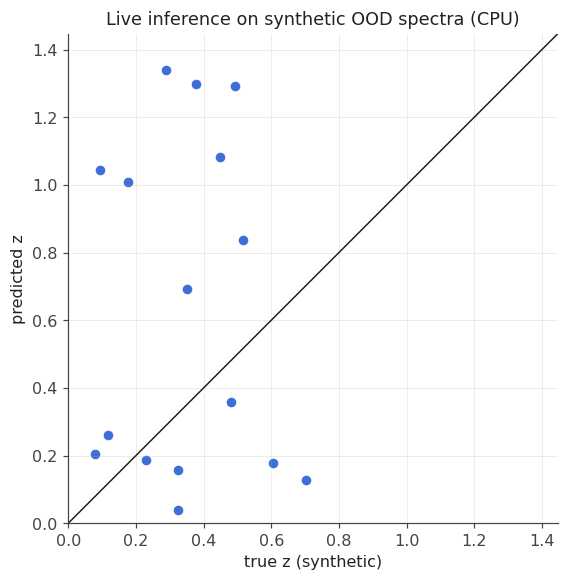

In [11]:
REST_LINES = {"[OII] 3727": 3727.0, "Ca K 3934": 3934.0, "Ca H 3969": 3969.0,
              "Hbeta 4861": 4861.0, "[OIII] 5007": 5007.0, "Halpha 6563": 6563.0}

def make_synthetic(z, rng, wave_in):
    fl = 0.5 + 0.15 * np.sin(wave_in / 700.0) + rng.normal(0.0, 0.05, wave_in.size)
    for lam in REST_LINES.values():
        obs = lam * (1.0 + z)
        if wave_in[0] <= obs <= wave_in[-1]:
            fl += float(rng.uniform(0.4, 1.2)) * np.exp(-0.5 * ((wave_in - obs) / 5.0) ** 2)
    return fl.astype(np.float32)

if LIVE:
    rng = np.random.default_rng(0)
    # deliberately NOT the model grid: linear spacing, different pixel count
    wave_in = np.linspace(3600.0, 9800.0, 6000).astype(np.float32)
    zt, zp = [], []
    for _ in range(16):
        z = float(rng.uniform(0.02, 0.8))
        res = predict_spectrum(flux=make_synthetic(z, rng, wave_in),
                               wavelength=wave_in, model=model)
        zt.append(z); zp.append(float(res["z_pred"]))
    lim = 1.08 * max(1.0, max(zt + zp))
    fig, ax = plt.subplots(figsize=(5.4, 5.4))
    ax.scatter(zt, zp, s=28, color=C_PRIMARY)
    zz = np.linspace(0.0, lim, 10)
    ax.plot(zz, zz, color=INK, lw=1.0)
    ax.set_xlim(0.0, lim); ax.set_ylim(0.0, lim); ax.set_aspect("equal")
    ax.set_xlabel("true z (synthetic)"); ax.set_ylabel("predicted z")
    ax.set_title("Live inference on synthetic OOD spectra (CPU)")
    plt.tight_layout(); plt.show()
else:
    print("(skipped)")


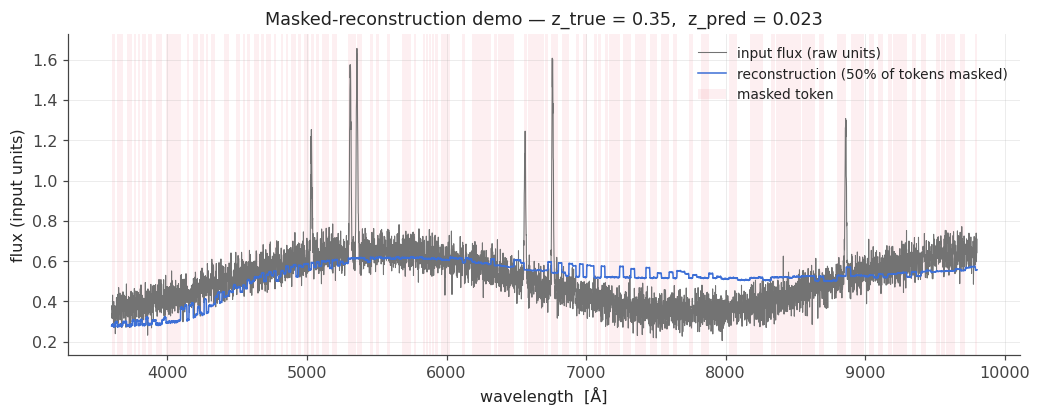

In [12]:
if LIVE:
    rng = np.random.default_rng(7)
    z_demo = 0.35
    fl = make_synthetic(z_demo, rng, wave_in)
    res = predict_spectrum(flux=fl, wavelength=wave_in, model=model, mask_ratio=0.5)
    mask_tok = res["spectrum_mask"]; mw = res["model_wavelength"]
    P = int(np.ceil(len(mw) / float(len(mask_tok))))
    fig, ax = plt.subplots(figsize=(9.6, 3.9))
    ax.plot(wave_in, fl, color="0.45", lw=0.7, label="input flux (raw units)")
    ax.plot(wave_in, res["reconstruction_input_grid"], color=C_PRIMARY, lw=1.0,
            label="reconstruction (50% of tokens masked)")
    lo, hi = ax.get_ylim()
    first = True
    for t in np.where(mask_tok)[0]:
        seg = mw[t * P: (t + 1) * P]
        if len(seg) == 0:
            continue
        ax.axvspan(float(seg[0]), float(seg[-1]), color=C_ACCENT, alpha=0.10, lw=0,
                   label="masked token" if first else None)
        first = False
    ax.set_ylim(lo, hi)
    ax.set_xlabel("wavelength  [Å]"); ax.set_ylabel("flux (input units)")
    ax.set_title("Masked-reconstruction demo — z_true = %.2f,  z_pred = %.3f"
                 % (z_demo, float(res["z_pred"])))
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("(skipped)")


## 5 · Summary

| metric (1000 held-out DESI spectra) | value |
|---|---|
| MAE_norm ⟨\|Δz\|/(1+z)⟩ | 0.120 |
| bias ⟨Δz⟩ | **−0.090** (median −0.024 → high-z tail) |
| σ_NMAD | 0.101 |
| catastrophic outlier fraction η₀.₁₅ | **25.1 %** (84–100 % for z > 1.5) |
| prediction ceiling | max z_pred ≈ 1.95 vs. max z_true ≈ 4.71 |
| masked-region reconstruction RMSE (arcsinh space) | 0.86 |

**Mapping to the grader feedback:**

- *"high bias"* → quantified in §1: a −0.09 mean offset produced almost entirely by
  z > 1 spectra being pulled down toward the bulk of the training distribution
  (regression-to-the-mean of a scalar regression head on an imbalanced z-distribution).
- *"large catastrophic outlier fraction"* → η₀.₁₅ = 25.1 %, dominated by
  line-misidentification degeneracies that a unimodal regression head averages
  instead of resolving.
- *"lacked a ready-to-run evaluation notebook and plots"* → this notebook, runnable
  offline from shipped artifacts.

**Next step:** the remediation recipe (classification head over log(1+z) bins,
z-rebalancing, longer training — with success criteria η₀.₁₅ < 10 %,
\|⟨Δz/(1+z)⟩\| < 0.02) is implemented as *Fase 0* of [`../plan/PLAN.md`](../plan/PLAN.md).
